# Exploratory Data Analysis (EDA)
## Dataset: Hotel Bookings
---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
try:
    df = pd.read_csv("../data/raw/hotel_bookings.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path.")

Dataset loaded successfully.


## 3. Jumlah Baris dan Kolom Dataset

In [4]:
jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]
nama_kolom = [col for col in df.columns]
print(f"Jumlah baris: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")
print(f"Nama kolom: {nama_kolom}")

Jumlah baris: 119390
Jumlah kolom: 32
Nama kolom: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


## 4. Lima Baris Data Teratas

In [5]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

## 5. Ringkasan Dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 6. Ringkasan Statistik Data Numerik

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 7. Cek Apakah Ada Missing Value

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## 8. Visualisasi Missing Value

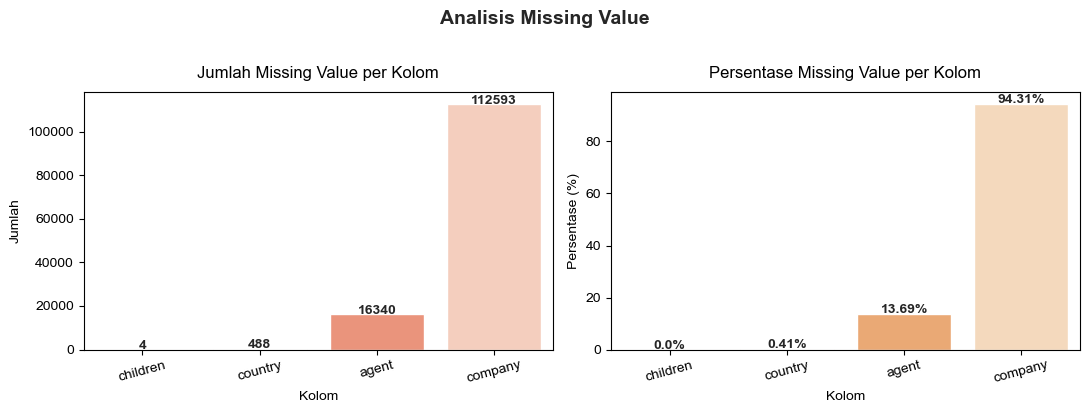

   Kolom  Jumlah Missing  Persentase (%)
children               4            0.00
 country             488            0.41
   agent           16340           13.69
 company          112593           94.31


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.set_style('whitegrid')

# Panel kiri: jumlah
bars1 = sns.barplot(data=missing, x='Kolom', y='Jumlah Missing',
                    palette='Reds_r', ax=axes[0])
for bar, val in zip(bars1.patches, missing['Jumlah Missing']):
    bars1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
               str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Jumlah Missing Value per Kolom', fontsize=12, pad=10)
axes[0].set_xlabel('Kolom')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)

# Panel kanan: persentase
bars2 = sns.barplot(data=missing, x='Kolom', y='Persentase (%)',
                    palette='Oranges_r', ax=axes[1])
for bar, val in zip(bars2.patches, missing['Persentase (%)']):
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
               f'{val}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Persentase Missing Value per Kolom', fontsize=12, pad=10)
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Analisis Missing Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(missing.to_string(index=False))

**Insight:** Kolom `company` memiliki **112.593 missing value (94.31%)** yang sangat tinggi sehingga perlu dipertimbangkan untuk dihapus. Kolom `agent` memiliki **16.340 missing value (13.69%)**, sedangkan `country` memiliki **488 missing value (0.41%)** dan `children` hanya **4 missing value (0.003%)**.

## 9. Cek Apakah Ada Duplicate Value

In [10]:
df.duplicated().sum()

np.int64(31994)

## 10. Visualisasi Duplicate Value

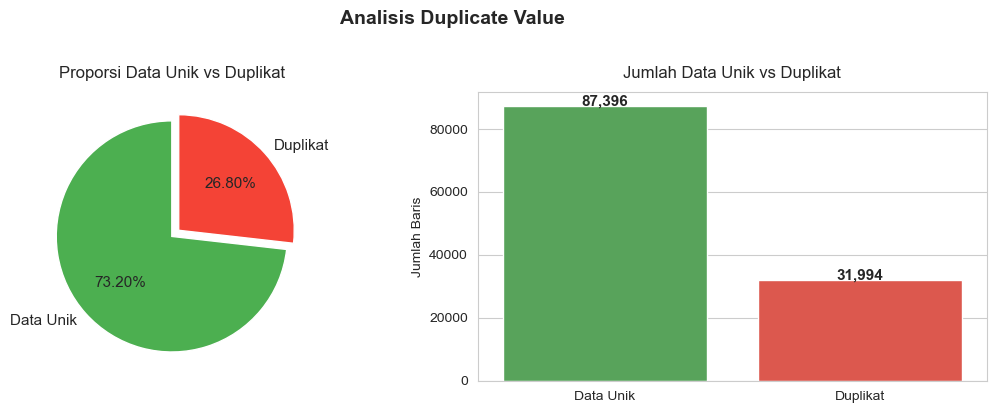

Total baris  : 119,390
Data unik    : 87,396
Duplikat     : 31,994


In [11]:
n_duplikat = df.duplicated().sum()
n_unik     = len(df) - n_duplikat

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel kiri: pie chart proporsi
labels  = ['Data Unik', 'Duplikat']
sizes   = [n_unik, n_duplikat]
colors  = ['#4CAF50', '#F44336']
explode = [0, 0.08]
axes[0].pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors,
            explode=explode, startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Proporsi Data Unik vs Duplikat', fontsize=12, pad=10)

# Panel kanan: bar chart perbandingan
bar_data = {'Kategori': ['Data Unik', 'Duplikat'], 'Jumlah': [n_unik, n_duplikat]}
bar_df = pd.DataFrame(bar_data)
bars = sns.barplot(data=bar_df, x='Kategori', y='Jumlah',
                   palette=['#4CAF50', '#F44336'], ax=axes[1])
for bar, val in zip(bars.patches, bar_df['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
              f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Data Unik vs Duplikat', fontsize=12, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Baris')

plt.suptitle('Analisis Duplicate Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total baris  : {len(df):,}")
print(f"Data unik    : {n_unik:,}")
print(f"Duplikat     : {n_duplikat:,}")

**Insight:** Dataset memiliki **31.994 baris duplikat (26.80%)** dari total 119.390 baris. Jumlah ini cukup signifikan sehingga perlu dilakukan penghapusan duplikat pada tahap preprocessing agar tidak mempengaruhi analisis.

## 11. Cek Apakah Ada Inconsistent Value

In [12]:
# Cek unique value hotel
print("Hotel types:", df['hotel'].unique())

# Cek unique value market_segment
print("\nMarket segments:", df['market_segment'].unique())

# Cek unique value customer_type
print("\nCustomer types:", df['customer_type'].unique())

# Cek unique value deposit_type
print("\nDeposit types:", df['deposit_type'].unique())

# Cek unique value meal
print("\nMeal types:", df['meal'].unique())

# Cek nilai adr negatif (tidak wajar)
print(f"\nJumlah ADR negatif: {(df['adr'] < 0).sum()}")
print(f"Nilai ADR maksimum: {df['adr'].max()}")

Hotel types: <ArrowStringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str

Market segments: <ArrowStringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str

Customer types: <ArrowStringArray>
['Transient', 'Contract', 'Transient-Party', 'Group']
Length: 4, dtype: str

Deposit types: <ArrowStringArray>
['No Deposit', 'Refundable', 'Non Refund']
Length: 3, dtype: str

Meal types: <ArrowStringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str

Jumlah ADR negatif: 1
Nilai ADR maksimum: 5400.0


**Insight:** Terdapat nilai `Undefined` pada kolom `market_segment` dan `meal` yang perlu ditangani. Nilai `adr` (Average Daily Rate) memiliki maksimum 5400 yang sangat tinggi dan perlu dicek sebagai outlier.

## 12. Grafik Distribusi Pembatalan Pemesanan

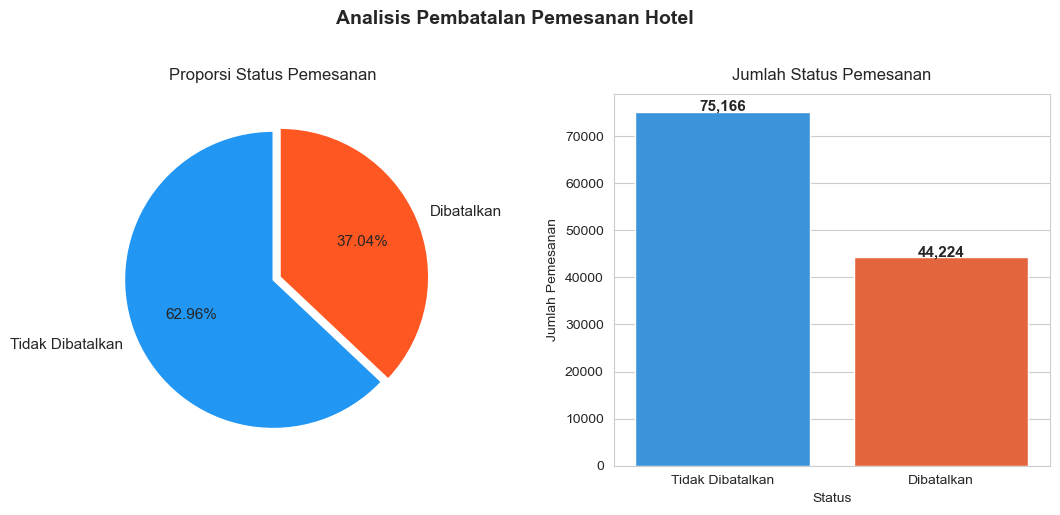

          Status  Jumlah
Tidak Dibatalkan   75166
      Dibatalkan   44224


In [13]:
sns.set_style('whitegrid')

cancel_counts = df['is_canceled'].value_counts().reset_index()
cancel_counts.columns = ['Status', 'Jumlah']
cancel_counts['Status'] = cancel_counts['Status'].map({0: 'Tidak Dibatalkan', 1: 'Dibatalkan'})

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Pie chart
colors = ['#2196F3', '#FF5722']
axes[0].pie(cancel_counts['Jumlah'], labels=cancel_counts['Status'],
            autopct='%1.2f%%', colors=colors, startangle=90,
            explode=[0, 0.05], textprops={'fontsize': 11})
axes[0].set_title('Proporsi Status Pemesanan', fontsize=12, pad=10)

# Bar chart
bars = sns.barplot(data=cancel_counts, x='Status', y='Jumlah',
                   palette=colors, ax=axes[1])
for bar, val in zip(bars.patches, cancel_counts['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
              f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Status Pemesanan', fontsize=12, pad=10)
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Jumlah Pemesanan')

plt.suptitle('Analisis Pembatalan Pemesanan Hotel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(cancel_counts.to_string(index=False))

**Insight:** Sebanyak **37.04%** pemesanan hotel mengalami pembatalan. Tingkat pembatalan yang cukup tinggi ini perlu dianalisis lebih lanjut untuk memahami faktor-faktor yang berkontribusi terhadap keputusan pembatalan.